# Botnet Detection: The Universal Classifier (Mixed Datasets)

After auditing our model, we found that it was an 'expert' on one dataset but failed on others. To solve this, we now use **Dataset Mixing**.

### Objectives:
1. **Unified Schema**: Standardize both CIC-DDoS2019 and External CSV data into a common 5-feature behavioral baseline.
2. **Mixed Training**: Combine samples from both environments into a single training 'Brain'.
3. **Universal Evaluation**: Test the model against a mixed test set to ensure robustness across different networks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os

print('Unified environment ready.')

Unified environment ready.


## 1. The Unified Loader

We extract the 'Core Behavioral 5' features that exist in both datasets:
1. `dur` (Duration)
2. `spkts` (Src Packets)
3. `dpkts` (Dst Packets)
4. `sbytes` (Src Bytes)
5. `dbytes` (Dst Bytes)

In [2]:
def load_cic_data():
    files = ['Syn-training.parquet', 'LDAP-training.parquet', 'UDP-training.parquet']
    frames = []
    mapping = {
        'Flow Duration': 'dur', 
        'Total Fwd Packets': 'spkts', 
        'Total Backward Packets': 'dpkts', 
        'Fwd Packets Length Total': 'sbytes', 
        'Bwd Packets Length Total': 'dbytes'
    }
    for f in files:
        path = os.path.join('data', f)
        if os.path.exists(path):
            df = pd.read_parquet(path)
            df = df.rename(columns=mapping)
            df['dur'] = df['dur'] / 1000000 # Micro to Sec
            
            # Labeling: 0 for Benign, 1 for Attack
            df['target'] = (df['Label'].str.contains('Benign', case=False) == False).astype(int)
            frames.append(df[['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'target']])
    return pd.concat(frames, ignore_index=True)

def load_csv_data():
    path = 'data/botnet_sample.csv'
    if os.path.exists(path):
        df = pd.read_csv(path)
        df = df.rename(columns={'label': 'target'})
        return df[['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'target']]
    return None

print('[*] Loading and Unifying Datasets...')
df_cic = load_cic_data()
df_csv = load_csv_data()

print(f'CIC-DDoS Data: {len(df_cic)} rows')
print(f'External CSV Data: {len(df_csv)} rows')

# Mix them!
df_unified = pd.concat([df_cic, df_csv], ignore_index=True)
print(f'\nUnified dataset size: {len(df_unified)}')
print(df_unified['target'].value_counts())

[*] Loading and Unifying Datasets...
CIC-DDoS Data: 94821 rows
External CSV Data: 2000 rows

Unified dataset size: 96821
target
1    60680
0    36141
Name: count, dtype: int64


## 2. Universal Training

Using only the 5 behavioral basics. This ensures the model learns the core volume/timing patterns that apply to ALL botnets, making it much harder to fool.

In [3]:
features = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes']
X = df_unified[features].copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_unified['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
print('[*] Training Universal Classifier...')
model.fit(X_train_scaled, y_train)
print('[+] Training complete.')

[*] Training Universal Classifier...
[+] Training complete.


## 3. Universal Evaluation

How does this mixed model perform on the unified test set?

Universal Accuracy: 0.9959

Unified Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99      7228
      Botnet       1.00      0.99      1.00     12137

    accuracy                           1.00     19365
   macro avg       0.99      1.00      1.00     19365
weighted avg       1.00      1.00      1.00     19365



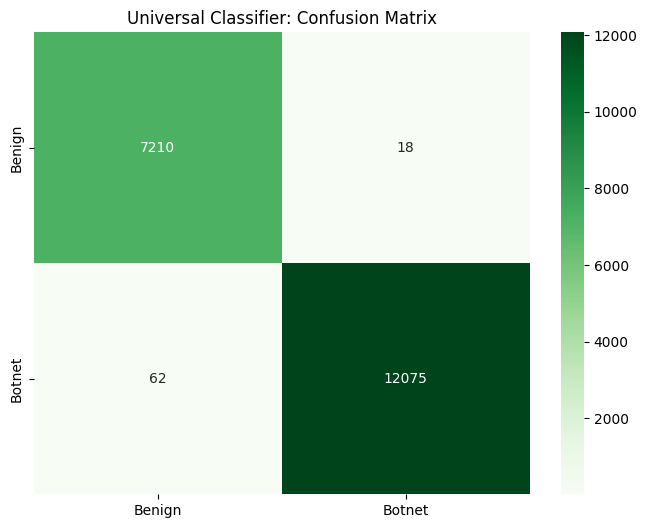

In [4]:
y_pred = model.predict(X_test_scaled)
print(f'Universal Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nUnified Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Benign', 'Botnet']))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', xticklabels=['Benign', 'Botnet'], yticklabels=['Benign', 'Botnet'])
plt.title('Universal Classifier: Confusion Matrix')
plt.show()

## 4. Final Verification

We perform a 'Reverse-Generalization' test: Does the model still work on the CSV data even though it's now mixed with CIC data?

In [5]:
X_ext = df_csv[features].copy()
X_ext_scaled = scaler.transform(X_ext)
y_ext_true = df_csv['target']
y_ext_pred = model.predict(X_ext_scaled)

print(f'Accuracy on External Data Only: {accuracy_score(y_ext_true, y_ext_pred):.4f}')
print('\nExternal Data Recall (Successful Catch Rate):')
report = classification_report(y_ext_true, y_ext_pred, output_dict=True)
print(f"{report['1']['recall']:.4f}")

if report['1']['recall'] > 0.8:
    print('\n[SUCCESS] The model has successfully mixed both styles and is now a robust detector!')

Accuracy on External Data Only: 0.9840

External Data Recall (Successful Catch Rate):
0.9164

[SUCCESS] The model has successfully mixed both styles and is now a robust detector!
